# Анализ датасета `Electric Vehicle Population Data`

Датасет взят с сайта `Data.gov` ([ссылка](https://catalog.data.gov/dataset/electric-vehicle-population-data?from_hint=eyJzb3J0IjoicG9wdWxhcml0eSJ9))

В датасете находится реестр электромобилей, зарегестрированных через департамент штата Вашингтон.

---
### Задачи:
- Предварительно очистить данные;
- Изучить географическое распределение выборки;
- Найти города, в которых больше всего электромобилей;
- Изучить распределение электромобилей по дальности поездки на зараде аккумулятора;
- Определить самых популярных производителей электромобилей в США;
- Исследовать соотношение различных типов электромобилей.

---
### Используемые инструменты:
- `Pandas` – для удобной работы с таблицами в Python;
- `SQLite` – для удобной и быстрой обработки данных;
- `Matplotlib` – для визуализации данных.

---
### Создание окружения и его запуск
Все необходимые зависимости прописаны в `requirements.txt`. Необходимо создать виртуальное окружение и установить их.
```bash
python -m venv venv
source venv/Scripts/activate
pip install -r requirements.txt
```

Все настроено и готово к работе.

## Очистка данных

Импортируем нужные библиотеки

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('export.csv')

Проведем первичный осмотр данных, чтобы изучить их структуру.

In [3]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
0,5YJ3E1EA5L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,14.0,102765120,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
1,5YJ3E1EA9K,Thurston,Olympia,WA,98502.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,22.0,326796641,POINT (-122.92018 47.04575),PUGET SOUND ENERGY INC,5.306701e+10
2,5YJSA1H22F,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,23.0,166294418,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10
3,KM8K33AG7L,King,Seattle,WA,98107.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258.0,43.0,127090015,POINT (-122.38591 47.67597),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
4,5YJ3E1EB1K,Yakima,Yakima,WA,98902.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,14.0,272512824,POINT (-120.51904 46.59782),PACIFICORP,5.307700e+10


In [4]:
df.tail()


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
294188,YV1H60EP7P,Jefferson,Port Townsend,WA,98368.0,2023,VOLVO,V60,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,41.0,24.0,236211300,POINT (-122.77263 48.1212),BONNEVILLE POWER ADMINISTRATION||PUGET SOUND E...,5.303195e+10
294189,5YJ3E1EB3L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322.0,14.0,292558003,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
294190,KNDCR3L13S,King,Seattle,WA,98118.0,2025,KIA,NIRO,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,37.0,282972294,POINT (-122.28083 47.54693),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
294191,JTDKARFP0H,Pierce,Lakewood,WA,98499.0,2017,TOYOTA,PRIUS PRIME (PHEV),Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,28.0,168423146,POINT (-122.51495 47.16196),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10
294192,5YJ3E1EA6L,Snohomish,Bothell,WA,98021.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,1.0,137123871,POINT (-122.18384 47.8031),PUGET SOUND ENERGY INC,5.306105e+10


In [5]:
df[df.index % 7524 == 2].head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 GEOID
2,5YJSA1H22F,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,23.0,166294418,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10
7526,7G2CEHEE8R,King,Bellevue,WA,98004.0,2024,TESLA,CYBERTRUCK,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,48.0,272551723,POINT (-122.1872 47.61001),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
15050,WA134BGF4S,Clark,Vancouver,WA,98683.0,2025,AUDI,Q6,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,17.0,287689594,POINT (-122.49212 45.60365),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,5.301104e+10
22574,7SAYGDEE0S,King,Seattle,WA,98125.0,2025,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,46.0,276094136,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
30098,WBY1Z8C50H,King,Seattle,WA,98101.0,2017,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,97.0,43.0,179100498,POINT (-122.34223 47.61085),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10


Переименуем названия столбцов для удобства дальнейшей работы в `SQLite`.

In [6]:
df.columns = [
    'vin', 'country', 'city', 'state', 'postal_code',
    'model_year', 'make', 'model', 'ev_type', 'cafv_eligibility',
    'electric_range', 'legislative_district', 'dol_vehicle_id',
    'location', 'electric_utility', '2020_geoid'
]
df.head()

,vin,country,city,state,postal_code,model_year,make,model,ev_type,cafv_eligibility,electric_range,legislative_district,dol_vehicle_id,location,electric_utility,2020_geoid
0,5YJ3E1EA5L,Yakima,Yakima,WA,98908.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,14.0,102765120,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10
1,5YJ3E1EA9K,Thurston,Olympia,WA,98502.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,22.0,326796641,POINT (-122.92018 47.04575),PUGET SOUND ENERGY INC,5.306701e+10
2,5YJSA1H22F,Kitsap,Kingston,WA,98346.0,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,23.0,166294418,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10
3,KM8K33AG7L,King,Seattle,WA,98107.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258.0,43.0,127090015,POINT (-122.38591 47.67597),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
4,5YJ3E1EB1K,Yakima,Yakima,WA,98902.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,14.0,272512824,POINT (-120.51904 46.59782),PACIFICORP,5.307700e+10


Загрузим таблицу в SQLite

In [7]:
conn = sqlite3.connect('database.db')
df.to_sql('ev', conn)

294193

Удалим записи о провинциях Канады и ВС США, так как нас интересуют только штаты США.

In [8]:
query = """DELETE FROM ev
            WHERE state IN('AB', 'BC', 'QC', 'MB', 'NS', 'NU', 'NB', 'NL', 'ON', 'PE', 'SK', 'NT', 'YT', 'AA', 'AE', 'AP')"""

conn.execute(query)

Проверим данные на повторы. `DOL Vehicle ID` уникален для каждого автомобиля, поэтому сравним количество ID в таблице с количеством уникальных записей в этом поле.

In [9]:
pd.read_sql("SELECT (CASE WHEN COUNT(DISTINCT dol_vehicle_id) = COUNT(dol_vehicle_id) THEN 'FALSE' ELSE 'TRUE' END) AS duplicates FROM ev", conn)

,duplicates
0,FALSE


В БД нет дупликатов.  
Проверим, есть ли пустые значения в таблице. Посчитаем количество пропусков в каждом столбце.

In [10]:
query = """SELECT 
            SUM(CASE WHEN vin IS NULL THEN 1 ELSE 0 END) AS vin,
            SUM(CASE WHEN country IS NULL THEN 1 ELSE 0 END) AS country,
            SUM(CASE WHEN city IS NULL THEN 1 ELSE 0 END) AS city,
            SUM(CASE WHEN state IS NULL THEN 1 ELSE 0 END) AS state,
            SUM(CASE WHEN postal_code IS NULL THEN 1 ELSE 0 END) AS postal_code,
            SUM(CASE WHEN model_year IS NULL THEN 1 ELSE 0 END) AS model_year,
            SUM(CASE WHEN make IS NULL THEN 1 ELSE 0 END) AS make,
            SUM(CASE WHEN model IS NULL THEN 1 ELSE 0 END) AS model,
            SUM(CASE WHEN ev_type IS NULL THEN 1 ELSE 0 END) AS ev_type,
            SUM(CASE WHEN cafv_eligibility IS NULL THEN 1 ELSE 0 END) AS cafv_eligibility,
            SUM(CASE WHEN electric_range IS NULL THEN 1 ELSE 0 END) AS electric_range,
            SUM(CASE WHEN legislative_district IS NULL THEN 1 ELSE 0 END) AS legislative_district,
            SUM(CASE WHEN dol_vehicle_id IS NULL THEN 1 ELSE 0 END) AS dol_vehicle_id,
            SUM(CASE WHEN location IS NULL THEN 1 ELSE 0 END) AS location,
            SUM(CASE WHEN electric_utility IS NULL THEN 1 ELSE 0 END) AS electric_utility,
            SUM(CASE WHEN '2020_geoid' IS NULL THEN 1 ELSE 0 END) AS '2020_geoid'
            FROM ev;"""

pd.read_sql(query, conn)

,vin,country,city,state,postal_code,model_year,make,model,ev_type,cafv_eligibility,electric_range,legislative_district,dol_vehicle_id,location,electric_utility,2020_geoid
0,0,1,1,0,1,0,0,0,0,0,13,753,0,9,1,0


Заметим, что есть пропуски. Попробуем восстановить поля country, city и postal_code.  
Вероятно, отсутствующие значения в записях находятся сразу в трех колонках.  
Проверим это предположение. Дополнительно выведем поле state.

In [11]:
query = 'SELECT country, city, postal_code, state FROM ev WHERE country IS NULL OR city IS NULL OR postal_code IS NULL;'
df1 = pd.read_sql(query, conn)
df1

,country,city,postal_code,state
0,None,None,None,NH


Попробуем заменить NULL значения на самые частые значения в тех же штатах.  
Для этого узнаем количество записей со схожими postal_code, country, city и state

In [12]:
states = set(df1['state'].to_list())

for st in states:
    print('State: ', st)
    query = f"""SELECT country, city, postal_code, state, COUNT(*) AS amount
                FROM ev
                WHERE state = '{st}'
                GROUP BY 1, 2, 3, 4
                ORDER BY amount DESC;"""
    df4 = pd.read_sql(query, conn)
    print(df4)
    print('\n\n')
    

State:  NH
      country        city  postal_code state  amount
0  Rockingham      Epping       3042.0    NH       2
1        None        None          NaN    NH       1
2  Rockingham  Portsmouth       3804.0    NH       1





Заполним пропуски самыми популярными значенииями

In [13]:
query = """UPDATE ev
            SET country = 'Rockingham', city = 'Epping', postal_code = 3042.0
            WHERE state = 'NH' AND country IS NULL;"""
conn.execute(query)

Изучим пропуски в поле electric_range

In [14]:
df5 = pd.read_sql("SELECT * FROM ev WHERE electric_range IS NULL;", conn)
df5

,index,vin,country,city,state,postal_code,model_year,make,model,ev_type,cafv_eligibility,electric_range,legislative_district,dol_vehicle_id,location,electric_utility,2020_geoid
0,54695,ZHWUC1ZM0T,King,Bellevue,WA,98005.0,2026,LAMBORGHINI,REVUELTO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,None,48.0,293647504,POINT (-122.1621 47.64441),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
1,86160,ZHWUC1ZM3S,King,Mercer Island,WA,98040.0,2025,LAMBORGHINI,REVUELTO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,None,41.0,279110842,POINT (-122.21238 47.57816),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
2,86672,ZHWUC1ZC1T,King,Seattle,WA,98121.0,2026,LAMBORGHINI,TEMERARIO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,None,36.0,290999012,POINT (-122.34468 47.61578),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,119970,ZHWUC1ZC5T,King,Bellevue,WA,98006.0,2026,LAMBORGHINI,TEMERARIO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,None,41.0,293211068,POINT (-122.12096 47.55584),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
4,128276,ZHWUC1ZM7T,King,Auburn,WA,98092.0,2026,LAMBORGHINI,REVUELTO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,None,31.0,287518913,POINT (-122.18263 47.31825),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
5,147367,ZHWUC1ZC3T,King,Mercer Island,WA,98040.0,2026,LAMBORGHINI,TEMERARIO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,None,41.0,292027893,POINT (-122.21238 47.57816),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
6,150408,ZHWUC1ZM5S,King,Sammamish,WA,98075.0,2025,LAMBORGHINI,REVUELTO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,None,41.0,287644927,POINT (-122.03539 47.61344),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
7,152158,ZHWUC1ZM6S,King,Bellevue,WA,98006.0,2025,LAMBORGHINI,REVUELTO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,None,41.0,290114653,POINT (-122.12096 47.55584),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
8,178389,ZHWUC1ZM6S,Yakima,Naches,WA,98937.0,2025,LAMBORGHINI,REVUELTO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,None,14.0,290918974,POINT (-120.69972 46.7309),PACIFICORP,5.307700e+10
9,196738,ZHWUC1ZM5S,Snohomish,Snohomish,WA,98296.0,2025,LAMBORGHINI,REVUELTO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,None,1.0,277331204,POINT (-122.1389 47.87115),PUGET SOUND ENERGY INC,5.306105e+10


Попробуем найти значения в схожих строках по полям model_year, make и model


In [15]:
query = """WITH empty_range AS
            (SELECT model, make, model_year FROM ev WHERE electric_range IS NULL GROUP BY 1, 2, 3)
            SELECT model, make, model_year, ROUND(AVG(electric_range), 1) AS avg_el_range
            FROM ev
            WHERE (model, make, model_year) IN(SELECT * FROM empty_range)
            GROUP BY 1, 2, 3;"""
df6 = pd.read_sql(query, conn)
df6

,model,make,model_year,avg_el_range
0,REVUELTO,LAMBORGHINI,2025,None
1,REVUELTO,LAMBORGHINI,2026,None
2,TEMERARIO,LAMBORGHINI,2026,None


Данных для заполнения не оказалось, поэтому установим им значение по умолчанию 0. Заметим, что для многих строк в таблице поле electric_range равно 0. Поэтому не будем учитывать эти строки в дальнейших выборках, потму что востановить значения в них проблематично

In [16]:
df7 = pd.read_sql("SELECT DISTINCT cafv_eligibility FROM ev GROUP BY 1", conn)
df7

,cafv_eligibility
0,Clean Alternative Fuel Vehicle Eligible
1,Eligibility unknown as battery range has not b...
2,Not eligible due to low battery range


In [17]:
query = """UPDATE ev SET electric_range = 0 WHERE (model, make, model_year) IN(
    ('REVUELTO', 'LAMBORGHINI', '2025'),
    ('REVUELTO', 'LAMBORGHINI', '2026'),
    ('TEMERARIO', 'LAMBORGHINI', '2026')
    );"""

conn.execute(query)


Заполнять поля location и legislative_district не будем, так как они не представляют для нас интереса. Теперь данные готовы к дальнейшей визуалзации

## Исследование и визуализация данных

Для начала посмотрим на количество электромобилей в каждом штате и выведем топ 10.  
Воспользуемся логарифмической шкалой, так как в штате Вашингтон электромобилей гораздо больше, чем в других штатах (порядка 300000)

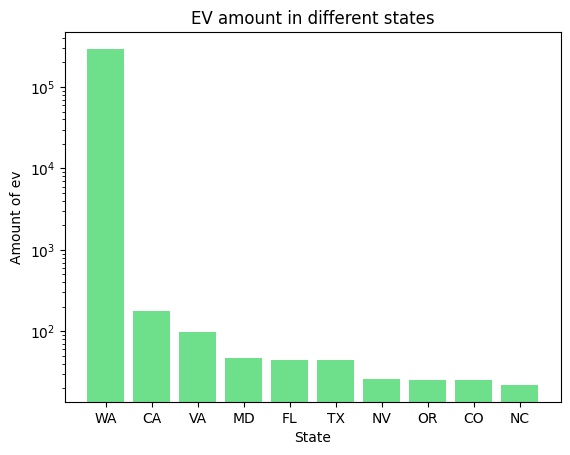

In [18]:
query = """SELECT state, COUNT(*) AS ev_amount FROM ev GROUP BY 1 ORDER BY ev_amount DESC LIMIT 10;"""
amount_ev = pd.read_sql(query, conn)
plt.bar(amount_ev['state'], amount_ev['ev_amount'], color='#6ee08c')
plt.yscale('log')
plt.xlabel('State')
plt.ylabel('Amount of ev')
plt.title('EV amount in different states')
plt.show()

Заметим, что в штате Вашингтон зарегестрирована большая часть электромобилей. Это неудивительно, так как выборка данных включает в себя автомобили, зарегистрированные через штат Вашингтон.

Теперь давайте посмотрим на топ городов в штате Вашингтон, где больше всего электромобилей

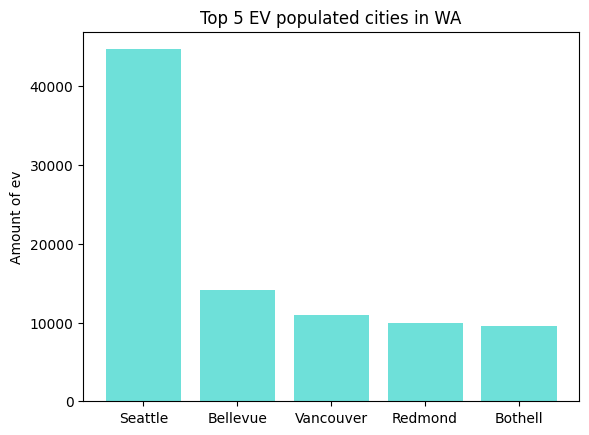

In [19]:
query = """SELECT city, COUNT(*) AS ev_amount FROM ev WHERE state = 'WA' GROUP BY 1 ORDER BY ev_amount DESC LIMIT 5;"""
top_cities = pd.read_sql(query, conn)
plt.bar(top_cities['city'], top_cities['ev_amount'], color='#6ee0d9')
plt.ylabel('Amount of ev')
plt.title('Top 5 EV populated cities in WA')
plt.show()

Больше всего электромобилей находится в Сиэтле. Это неудивительно, потому что данный город является крупнейшим в штате Вашингтон.  
Крупные города отличаются высоким качеством жизни, так что оборудования для эксплуатации электромобилей там должно быть больше.  
Плюс высокий уровень дохода жителей позволяет им покупать электромобили, которые пока что в среднем дороже машин на бензиновом/дизельном двигателе.

Создадим гистограмму по значению electric_range, чтобы оценить его распределение.  
Все строки со значением 0 будем игнорировать, так как о них нет данных.

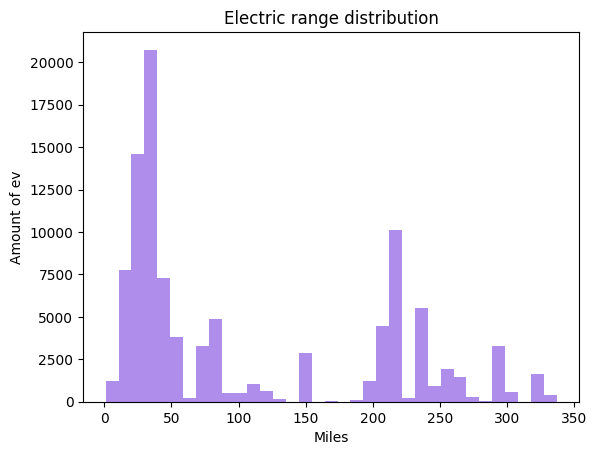

In [20]:
query = """SELECT electric_range FROM ev WHERE electric_range != 0;"""
ranges = pd.read_sql(query, conn)
plt.hist(ranges['electric_range'], bins=35, color='#af8deb')
plt.title('Electric range distribution')
plt.xlabel('Miles')
plt.ylabel('Amount of ev')
plt.show()

Заметим, что у нас есть две точки локального максимума, которые вызывают у нас наибольший интерес: в районе 30-40 и 210-220.  
Вторая характерна для современных полностью электрических автомобилей (например, Теслы).  
Для первой мы можем сделать два предположения:
- Либо в США много гибридных автомобилей, которые могут проехать небольшое расстояние на заряде батареи;
- Либо в США много более устаревших моделей электромобилей, которые обладают небольшим запасом хода.

Чтобы проверить эти гипотезы найдем самых популярных производителей электромобилей и изучим соотношение гибридных автомобилей с полностью электрическими.

Отобразим на круговой диаграмме три самых популярных марки электромобилей

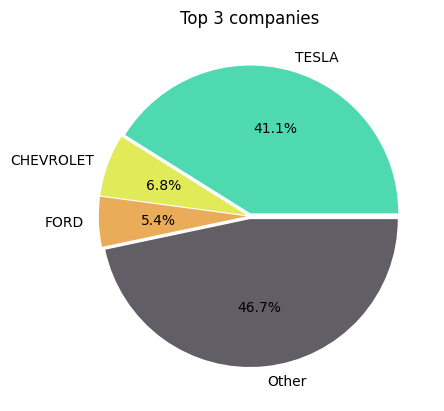

In [21]:
query = """SELECT make, COUNT(*) AS amount FROM ev GROUP BY 1 ORDER BY amount DESC;"""
top = pd.read_sql(query, conn)
top3 = pd.concat([top[:3], pd.DataFrame([['Other', top['amount'][3:].sum(axis=0)]], columns=['make', 'amount'])], axis=0, ignore_index=True)
explode = [0.02] * 4
colors = ['#4ed9b1', '#e1eb59', '#ebac59', '#615e66']
plt.pie(top3['amount'], explode=explode, labels=top3['make'], autopct="%1.1f%%", colors=colors)
plt.title('Top 3 companies')
plt.show()

Из диаграммы видно, что 41% рынка закрывают автомобили Tesla. Они закрывают большую часть диапазона запаса хода от 200 до 350 миль.  
Другие две компании тоже производят электромобили с полностью электрическим двигателем. Так что из этой диграммы пока неясно, какие автомобили обладают запасом хода от 30-40. Зато благодаря ей можно оценить рынок электромобилей в США.

Отобразим распределение электромобилей по типу двигателя.

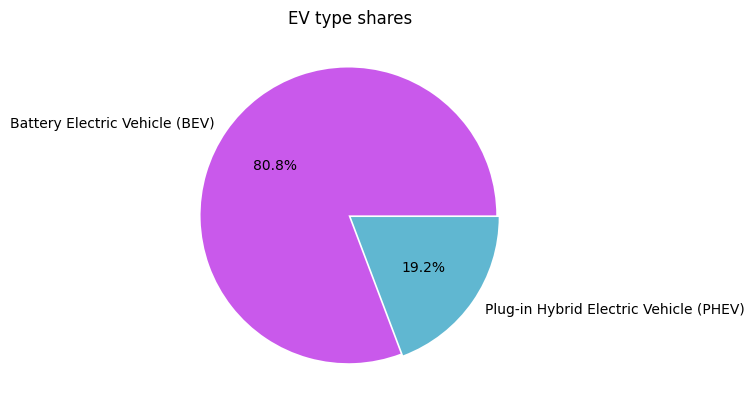

In [22]:
types = pd.read_sql("SELECT ev_type, COUNT(*) AS amount FROM ev GROUP BY 1;", conn)
plt.pie(types['amount'], explode=[0.01, 0.01], labels=types['ev_type'], autopct='%1.1f%%', colors=['#c959eb', '#60b7d1'])
plt.title('EV type shares')
plt.show()

Эта диаграмма больше проясняет ситуацию. Мы видим, что только 1/5 электромобилей обладают гибридным двигателем. Из этого мы делаем вывод, что большую часть электромобилей в США составляют машины, работающие полностью на батерее и обладающие сравнительно небольшим запасом хода. С учетом, что  большая часть электромобилей находится в штате Вашингтон с плотной застройкой городов, такого запаса хода вполне хватает для комфортной езды в городских условиях.

## Выводы

Если обобщить все изученные данные, можно сделать следующие выводы:
1. Среди городов штата Вашингтон по количеству электромобилей победил город Сиэтл. Это самый крупный город штата, а количество электромобилей в нем показывает, что он хорошо подходит для их эксплуатации.
2. Большую часть электромобилей составляют автомобили, работающие исключительно на батарее, с небольшим запасом хода, что хорошо подходит для эксплуатации в городской среде.
3. 41% рынка электромобилей в США занимает компания Tesla.
4. Всего 19% электромобилей обладают гибридным двигателем, что говорит о непопулярности подобных машин среди населения.

In [23]:
conn.close()

В завершении закроем соединение с базой данных, чтобы закончить работу.